In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

We are exploring the Titanic dataset to understand patterns in passenger survival.

Load the data

In [ ]:
df=pd.read_csv("titanic.csv")


loads the dataset

In [ ]:
print(len(df))

total 891 rows in this dataframe

In [ ]:
print(df.shape[1])

12 columns in the  dataframe

In [ ]:
print(df.columns)

column_names=PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'

In [ ]:
print(df.isnull().sum())

null values in columns
Age =177
cabin=687
Embarked=2

In [ ]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str

CLeaning the data

In [ ]:
df.drop(columns=["Cabin"], inplace=True)

removed Cabin column becuase it have more missing values

In [ ]:
df["Age"]=df['Age'].fillna(df['Age'].mean())

replces missing value in 'Age' column with Mean of Age 

In [ ]:
df=df.dropna(subset=["Embarked"])

removed rows of a colum with missing value

General Information

In [ ]:
total_passengers=df['PassengerId'].count()
print(total_passengers)

total of 889 passengers with all data available 

In [ ]:
print((df["Sex"]=="male").sum())

total 577 male passengers 

In [ ]:
print((df["Sex"]=="female").sum())

total 312 male passengers 

In [ ]:
print(df["Age"].min())

youngest passenger is '0.42'years old

In [ ]:
print(df["Age"].max())

oldest passenger is '80'years old

In [ ]:
print(df["Age"].mean().round(2))

Average Age of a passenger is '29.65'years old

In [ ]:
print(df["Fare"].mean().round(2))

Average fare of passenger is '32.1'

Passenger Class Analysis

In [ ]:
pclass_1=(df["Pclass"]==1).sum()
print(pclass_1)

Total of '214' passengers in 1 class

In [ ]:
pclass_2=(df["Pclass"]==2).sum()
print(pclass_2)

Total of '184' passengers in 2 class

In [ ]:
pclass_3=(df["Pclass"]==3).sum()
print(pclass_3)

Total of '491' passengers in 3 class

In [ ]:
print(df.groupby("Pclass")['Fare'].sum())

Pclass 1 passengers paid highest fair

In [ ]:
print(df.groupby("Pclass")['Age'].mean())

Pclass 1 had  highest average age

Survival Analysis

In [ ]:
survived=(df["Survived"]==1).sum()
print(survived)

Total of "340" Passengers Survived

In [ ]:
died=(df["Survived"]==0).sum()
print(died)

Total of "549" Passengers Survived

In [ ]:
percentage_of_surval=(survived/total_passengers)*100
print(percentage_of_surval.round(2))

Survival rate was 38.25%

In [ ]:
print(((df['Sex']=='male')& (df['Survived']==1)).sum())

109 male passengers survived

In [ ]:
print(((df['Sex']=='female')& (df['Survived']==1)).sum())

231 female passengers survived

In [ ]:
print(((df['Pclass']==1)& (df['Survived']==1)).sum())
print(((df['Pclass']==2)& (df['Survived']==1)).sum())
print(((df['Pclass']==3)& (df['Survived']==1)).sum())

134 passengers from pclass 1 survived
87 passengers from pclass 2 survived
119 passengers from pclass 3 survived

Age Analysis

In [ ]:
print((df.groupby("Sex")['Age'].mean()).round(2))

female    28.08
male      30.51

In [ ]:
child=(df["Age"]<18).sum()
print(child)

113 children

In [ ]:
adult=((df["Age"]>=18)&(df['Age']<60)).sum()
print(adult)

725 adults

In [215]:
senior=(df["Age"]>=60).sum()
print(senior)

25


21 senior citizens

Charts

In [ ]:
data=[percentage_of_surval,100-percentage_of_surval]
labels=["Survived",'Died']
plt.pie(data,labels=labels,autopct='%1.1f%%')
plt.title("Survival data")
plt.show()

pie chart of survial/death data percentage

In [ ]:
data=[pclass_1,pclass_2,pclass_3]
labels=['Pclass1','Pclass2','Pclass3']
plt.bar(labels,data,color=['#dd37e6','#37e68f','#80e637'])
plt.title('Pclass ')
plt.tight_layout()
plt.xlabel('Classes')
plt.ylabel('No of passengers')

Bar chart of Passenger class

In [ ]:
data=[child,adult,senior]
labels=["child",'adult','senior']
plt.barh(labels,data,color=['orange','yellow','green'])
plt.title("Age classification")

plt.tight_layout()
plt.xlabel('No of')
plt.ylabel('types')

BarH chart of Age distributin

In [ ]:
male=(df["Sex"]=='male').sum()
female=(df["Sex"]=='female').sum()


data=[male,female]
labels=['Male','Female']
plt.pie(data,labels=labels,colors=['blue','pink'],autopct='%1.1f%%')


pie chart of Gender distribution

<BarContainer object of 3 artists>

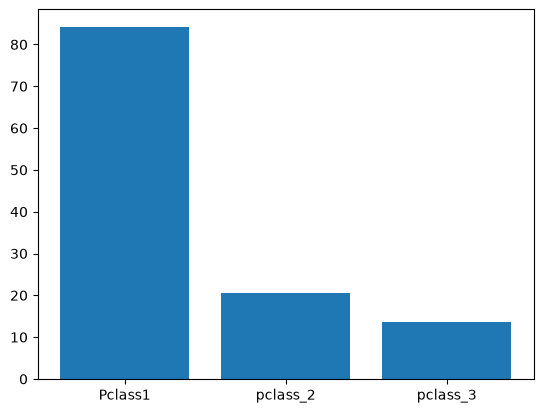

In [214]:
fare_dist=(df.groupby("Pclass")['Fare'].mean()).round(2)
labels=["Pclass1","pclass_2","pclass_3"]
plt.bar(labels,fare_dist)

fare distrubion using bar chart

Conclusions

In [ ]:
#print((df.groupby("Pclass")['Age'].mean()).round(2))

Which gender survived more?

Female Passengers of 231 Survived

Which passenger class had the highest survival rate?

Pclass 1 has the highest survival rate

Were first-class passengers generally older

Yes pclass 1 passengers were older , pclass 1 mean age  value is 36.93

What surprised you?

The females Were survived more and Most of the male passengers survived were from pclass1. The more money paid more chance to survive 